In [1]:
import torch
import matplotlib.pyplot as plt

from laya.calibration import (
    accuracy,
    brier_score,
    neg_log_likelihood,
    expected_calibration_error,
)

calibration


In [3]:
targets = torch.tensor(
    [
        0,
        1,
        2,
        0,
        1,
        2,
    ]
)
probs_a = torch.tensor(
    [
        [0.70, 0.20, 0.10],
        [0.10, 0.80, 0.10],
        [0.10, 0.20, 0.70],
        [0.60, 0.30, 0.10],
        [0.20, 0.60, 0.20],
        [0.10, 0.20, 0.70],
    ]
)

accuracy(probs_a, targets), neg_log_likelihood(probs_a, targets), brier_score(
    probs_a, targets
)

(tensor(1.), tensor(0.3858), tensor(0.1633))

In [4]:
probs_b = torch.tensor(
    [
        [0.99, 0.005, 0.005],
        [0.005, 0.99, 0.005],
        [0.005, 0.005, 0.99],
        [0.99, 0.005, 0.005],
        [0.99, 0.005, 0.005],
        [0.005, 0.005, 0.99],
    ]
)

for name, probabilities in [
    ("A", probs_a),
    ("B", probs_b),
]:
    print(
        name,
        "accuracy=",
        accuracy(
            probabilities,
            targets,
        ).item(),
        "nll=",
        neg_log_likelihood(
            probabilities,
            targets,
        ).item(),
        "brier=",
        brier_score(
            probabilities,
            targets,
        ).item(),
    )

A accuracy= 1.0 nll= 0.3858032524585724 brier= 0.16333334147930145
B accuracy= 0.8333333134651184 nll= 0.8914281725883484 brier= 0.32848331332206726


ece


In [ ]:
for name, probabilities in [
    ("A", probs_a),
    ("B", probs_b),
]:
    print(
        name,
        expected_calibration_error(
            probabilities,
            targets,
            n_bins=5,
        ).item(),
    )

A 0.3166666626930237
B 0.15666663646697998


In [6]:
torch.manual_seed(42)

n = 1000

confidences = 0.5 + 0.5 * torch.rand(n)

correct = torch.rand(n) < confidences

In [7]:
predicted_classes = torch.zeros(
    n,
    dtype=torch.long,
)

targets_calibrated = torch.where(
    correct,
    predicted_classes,
    torch.ones_like(predicted_classes),
)

probs_calibrated = torch.stack(
    [
        confidences,
        1 - confidences,
    ],
    dim=1,
)
expected_calibration_error(
    probs_calibrated,
    targets_calibrated,
    n_bins=10,
)

tensor(0.0277)

In [9]:
reported_confidences = 0.5 + 0.5 * ((confidences - 0.5) / 0.5).pow(0.5)

probs_overconfident = torch.stack(
    [
        reported_confidences,
        1 - reported_confidences,
    ],
    dim=1,
)

expected_calibration_error(
    probs_overconfident,
    targets_calibrated,
    n_bins=10,
)

tensor(0.0777)

In [ ]:
def reliability_points(
    probabilities,
    targets,
    n_bins=10,
):
    confidences, predictions = probabilities.max(dim=-1)

    correct = (predictions == targets).float()

    boundaries = torch.linspace(
        0,
        1,
        n_bins + 1,
    )

    bin_confidences = []
    bin_accuracies = []

    for i in range(n_bins):
        lower = boundaries[i]
        upper = boundaries[i + 1]

        in_bin = (confidences > lower) & (confidences <= upper)

        if not in_bin.any():
            continue

        bin_confidences.append(confidences[in_bin].mean().item())

        bin_accuracies.append(correct[in_bin].mean().item())

    return (
        bin_confidences,
        bin_accuracies,
    )

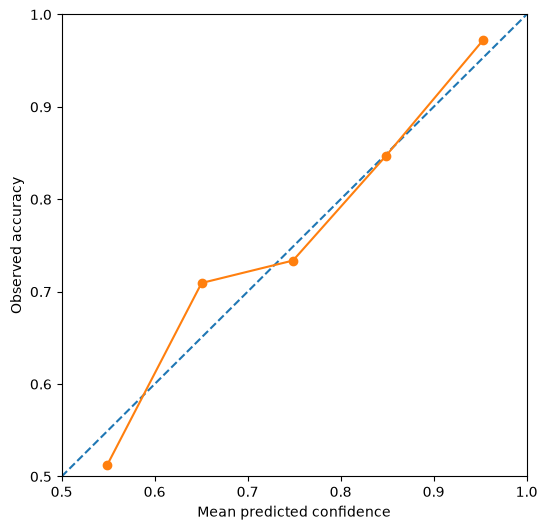

In [11]:
x, y = reliability_points(
    probs_calibrated,
    targets_calibrated,
)

plt.figure(figsize=(6, 6))

plt.plot(
    [0, 1],
    [0, 1],
    "--",
)

plt.plot(
    x,
    y,
    marker="o",
)

plt.xlabel("Mean predicted confidence")
plt.ylabel("Observed accuracy")

plt.xlim(0.5, 1.0)
plt.ylim(0.5, 1.0)

plt.show()

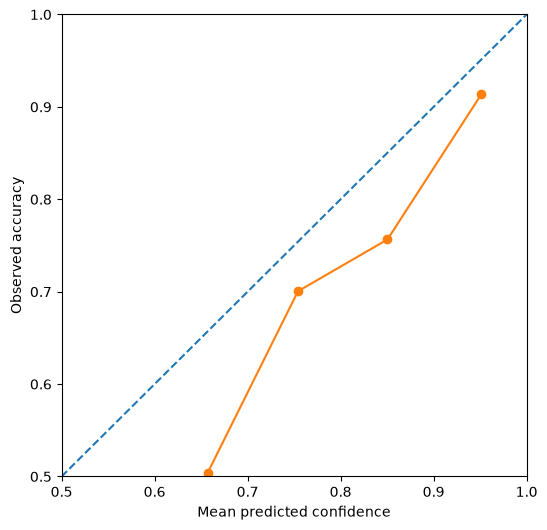

In [12]:
x, y = reliability_points(
    probs_overconfident,
    targets_calibrated,
)

plt.figure(figsize=(6, 6))

plt.plot(
    [0, 1],
    [0, 1],
    "--",
)

plt.plot(
    x,
    y,
    marker="o",
)

plt.xlabel("Mean predicted confidence")
plt.ylabel("Observed accuracy")

plt.xlim(0.5, 1.0)
plt.ylim(0.5, 1.0)

plt.show()

In [ ]:
hard_predictions_calibrated = probs_calibrated.argmax(dim=-1)

hard_predictions_overconfident = probs_overconfident.argmax(dim=-1)

torch.equal(
    hard_predictions_calibrated,
    hard_predictions_overconfident,
)

True

In [ ]:
expected_calibration_error(
    probs_calibrated,
    targets_calibrated,
), expected_calibration_error(
    probs_overconfident,
    targets_calibrated,
)

(tensor(0.0277), tensor(0.0777))